In [3]:
import pandas as pd

# Load the JSON data into a pandas DataFrame
df = pd.read_json('C:/Users/inesm/OneDrive/Documentos/dego-project-team11-TXC/notebooks/raw_credit_applications.json')

# Display the first few rows of the DataFrame
print("DataFrame loaded successfully. First 5 rows:")
df.head()

DataFrame loaded successfully. First 5 rows:


,_id,applicant_info,financials,spending_behavior,decision,processing_timestamp,loan_purpose,notes
0,app_200,"{'full_name': 'Jerry Smith', 'email': 'jerry.s...","{'annual_income': 73000, 'credit_history_month...","[{'category': 'Shopping', 'amount': 480}, {'ca...","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,"{'full_name': 'Brandon Walker', 'email': 'bran...","{'annual_income': 78000, 'credit_history_month...","[{'category': 'Rent', 'amount': 608}, {'catego...","{'loan_approved': False, 'rejection_reason': '...",NaN,NaN,NaN
2,app_215,"{'full_name': 'Scott Moore', 'email': 'scott.m...","{'annual_income': 61000, 'credit_history_month...","[{'category': 'Rent', 'amount': 109}]","{'loan_approved': True, 'interest_rate': 3.7, ...",NaN,vacation,NaN
3,app_024,"{'full_name': 'Thomas Lee', 'email': 'thomas.l...","{'annual_income': 103000, 'credit_history_mont...","[{'category': 'Fitness', 'amount': 575}]","{'loan_approved': True, 'interest_rate': 4.3, ...",NaN,NaN,NaN
4,app_184,"{'full_name': 'Brian Rodriguez', 'email': 'bri...","{'annual_income': 57000, 'credit_history_month...","[{'category': 'Entertainment', 'amount': 463}]","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN


#### **Understand Data Structure and Alignement**

Inspect the DataFrame's structure using `.info()`, display column names, and confirm the initial data structure with `.head()` to ensure alignment. Get a summary of the columns, their data types, and non-null values. Then, print `df.columns` to list all column names, and finally use `df.head()` to visually confirm the data's initial structure.

In [4]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Columns:")
print(df.columns)

print("\nDataFrame Head:")
df.head()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   _id                   502 non-null    object
 1   applicant_info        502 non-null    object
 2   financials            502 non-null    object
 3   spending_behavior     502 non-null    object
 4   decision              502 non-null    object
 5   processing_timestamp  62 non-null     object
 6   loan_purpose          50 non-null     object
 7   notes                 2 non-null      object
dtypes: object(8)
memory usage: 31.5+ KB

DataFrame Columns:
Index(['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision',
       'processing_timestamp', 'loan_purpose', 'notes'],
      dtype='object')

DataFrame Head:


,_id,applicant_info,financials,spending_behavior,decision,processing_timestamp,loan_purpose,notes
0,app_200,"{'full_name': 'Jerry Smith', 'email': 'jerry.s...","{'annual_income': 73000, 'credit_history_month...","[{'category': 'Shopping', 'amount': 480}, {'ca...","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN
1,app_037,"{'full_name': 'Brandon Walker', 'email': 'bran...","{'annual_income': 78000, 'credit_history_month...","[{'category': 'Rent', 'amount': 608}, {'catego...","{'loan_approved': False, 'rejection_reason': '...",NaN,NaN,NaN
2,app_215,"{'full_name': 'Scott Moore', 'email': 'scott.m...","{'annual_income': 61000, 'credit_history_month...","[{'category': 'Rent', 'amount': 109}]","{'loan_approved': True, 'interest_rate': 3.7, ...",NaN,vacation,NaN
3,app_024,"{'full_name': 'Thomas Lee', 'email': 'thomas.l...","{'annual_income': 103000, 'credit_history_mont...","[{'category': 'Fitness', 'amount': 575}]","{'loan_approved': True, 'interest_rate': 4.3, ...",NaN,NaN,NaN
4,app_184,"{'full_name': 'Brian Rodriguez', 'email': 'bri...","{'annual_income': 57000, 'credit_history_month...","[{'category': 'Entertainment', 'amount': 463}]","{'loan_approved': False, 'rejection_reason': '...",2024-01-15T00:00:00Z,NaN,NaN


#### **Analyze Data Distributions**

Generate descriptive statistics for numerical columns and examine unique values and their frequencies for categorical columns after flattening nested JSON data.

Flatten the nested JSON columns (`applicant_info`, `financials`, `decision`) into new columns and then concatenate them with the original DataFrame, dropping the original nested columns. This is the first step in preparing the data for distribution analysis.


In [5]:
applicant_info_df = pd.json_normalize(df['applicant_info'])
financials_df = pd.json_normalize(df['financials'])
decision_df = pd.json_normalize(df['decision'])

# Concatenate the flattened dataframes with the original df and drop the original nested columns
df = pd.concat([df.drop(columns=['applicant_info', 'financials', 'decision']), applicant_info_df, financials_df, decision_df], axis=1)

print("DataFrame after flattening nested columns:")
print(df.head())

DataFrame after flattening nested columns:
       _id                                  spending_behavior  \
0  app_200  [{'category': 'Shopping', 'amount': 480}, {'ca...   
1  app_037  [{'category': 'Rent', 'amount': 608}, {'catego...   
2  app_215              [{'category': 'Rent', 'amount': 109}]   
3  app_024           [{'category': 'Fitness', 'amount': 575}]   
4  app_184     [{'category': 'Entertainment', 'amount': 463}]   

   processing_timestamp loan_purpose notes        full_name  \
0  2024-01-15T00:00:00Z          NaN   NaN      Jerry Smith   
1                   NaN          NaN   NaN   Brandon Walker   
2                   NaN     vacation   NaN      Scott Moore   
3                   NaN          NaN   NaN       Thomas Lee   
4  2024-01-15T00:00:00Z          NaN   NaN  Brian Rodriguez   

                        email          ssn      ip_address gender  ...  \
0   jerry.smith17@hotmail.com  596-64-4340  192.168.48.155   Male  ...   
1   brandon.walker2@yahoo.com  425-69-4

Next follow the calculations of the total spending for each applicant from the `spending_behavior` column, handling cases where the list might be empty or `NaN`, and store it in a new column named `total_spending`.

In [6]:
def calculate_total_spending(spending_list):
    if isinstance(spending_list, list):
        return sum(item.get('amount', 0) for item in spending_list)
    return 0

df['total_spending'] = df['spending_behavior'].apply(calculate_total_spending)

print("DataFrame after calculating total spending:")
print(df[['_id', 'spending_behavior', 'total_spending']].head())

DataFrame after calculating total spending:
       _id                                  spending_behavior  total_spending
0  app_200  [{'category': 'Shopping', 'amount': 480}, {'ca...            1517
1  app_037  [{'category': 'Rent', 'amount': 608}, {'catego...             947
2  app_215              [{'category': 'Rent', 'amount': 109}]             109
3  app_024           [{'category': 'Fitness', 'amount': 575}]             575
4  app_184     [{'category': 'Entertainment', 'amount': 463}]             463


A `KeyError`was encountered when attempting to convert the `dob` column to datetime objects using `pd.to_datetime`, to ensure it is in the correct format for any time-based analysis, as per the instructions.

This happened because the `dob` column was not found in the DataFrame. To prevent this error and ensure robust execution, the following steps check if the `dob` column exists. If it does, it proceeds with converting it to datetime objects. If it does not exist, a warning message indicating that the column is missing and skip the conversion is logged, allowing subsequent steps to proceed without error.

In [7]:
if 'dob' in df.columns:
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

    print("DataFrame after converting 'dob' to datetime:")
    print(df[['_id', 'dob']].head())
else:
    print("Warning: 'dob' column not found in DataFrame. Skipping datetime conversion for 'dob'.")
    print("Current DataFrame columns:")
    print(df.columns)

Current DataFrame columns:
Index(['_id', 'spending_behavior', 'processing_timestamp', 'loan_purpose',
       'notes', 'full_name', 'email', 'ssn', 'ip_address', 'gender',
       'date_of_birth', 'zip_code', 'annual_income', 'credit_history_months',
       'debt_to_income', 'savings_balance', 'annual_salary', 'loan_approved',
       'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending'],
      dtype='object')


Since the `dob` column was not found but `date_of_birth` exists, there is still the need to convert the specified numerical columns (`annual_income`, `credit_history_months`, `debt_to_income`, `interest_rate`, `approved_amount`, and `total_spending`) to their appropriate numeric types. This is done by replacing `debt_to_income_ratio` with `debt_to_income` and `loan_amount` with `approved_amount` based on the DataFrame's actual columns.

In [8]:
columns_to_numeric = ['annual_income', 'credit_history_months', 'debt_to_income', 'interest_rate', 'approved_amount', 'total_spending']

for col in columns_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Column '{col}' converted to numeric type.")
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping numeric conversion.")

print("\nDataFrame dtypes after numeric conversions:")
print(df[columns_to_numeric].dtypes)

Column 'annual_income' converted to numeric type.
Column 'credit_history_months' converted to numeric type.
Column 'debt_to_income' converted to numeric type.
Column 'interest_rate' converted to numeric type.
Column 'approved_amount' converted to numeric type.
Column 'total_spending' converted to numeric type.

DataFrame dtypes after numeric conversions:
annual_income            float64
credit_history_months      int64
debt_to_income           float64
interest_rate            float64
approved_amount          float64
total_spending             int64
dtype: object


#### **Descriptive Statistics**

The next step generates descriptive statistics for all numerical columns in the updated DataFrame using the `.describe()` method to understand their central tendency, dispersion, and shape.

In [9]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
       annual_income  credit_history_months  debt_to_income  savings_balance  \
count     497.000000             502.000000      502.000000       502.000000   
mean    82705.096155              50.402390        0.246195     29493.503984   
std     28101.977862              31.234824        0.136296     16775.309756   
min         0.000000             -10.000000        0.050000     -5000.000000   
25%     63000.000000              27.250000        0.150000     17258.250000   
50%     81000.000000              48.000000        0.230000     27385.500000   
75%    101000.000000              72.000000        0.350000     38251.500000   
max    171000.000000             133.000000        1.850000     88078.000000   

       annual_salary  interest_rate  approved_amount  total_spending  
count       5.000000     292.000000       292.000000      502.000000  
mean    69200.000000       4.564726     47845.890411      790.615538  
std     22664.95091

The next step examines the unique values and their frequencies for the key categorical columns: `gender`, `employment_status`, `loan_purpose`, `loan_approved`, and `rejection_reason`. This will provide insights into the distribution of categorical data.

In [10]:
categorical_columns = ['gender', 'employment_status', 'loan_purpose', 'loan_approved', 'rejection_reason']

print("\nUnique values and frequencies for categorical columns:")
for col in categorical_columns:
    if col in df.columns:
        print(f"\n--- Column: {col} ---")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"\nWarning: Column '{col}' not found in DataFrame. Skipping frequency count.")


Unique values and frequencies for categorical columns:

--- Column: gender ---
gender
Male      195
Female    193
F          58
M          53
            2
NaN         1
Name: count, dtype: int64


--- Column: loan_purpose ---
loan_purpose
NaN                   452
medical                 8
education               7
wedding                 6
vacation                6
debt_consolidation      6
moving                  5
personal                4
auto                    3
home_improvement        3
business                2
Name: count, dtype: int64

--- Column: loan_approved ---
loan_approved
True     292
False    210
Name: count, dtype: int64

--- Column: rejection_reason ---
rejection_reason
NaN                            292
algorithm_risk_score           170
insufficient_credit_history     23
high_dti_ratio                  13
low_income                       4
Name: count, dtype: int64


#### **Some important assumptions retrived from previous analysis from this notebook**:
* Considering the conversion of the `dob` column to datetime as an important step.

* Assuming that after flattening, the column is named `date_of_birth`.

The next step will convert `date_of_birth` to datetime objects to fully handle date information.

In [11]:
if 'date_of_birth' in df.columns:
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

    print("DataFrame after converting 'date_of_birth' to datetime:")
    print(df[['_id', 'date_of_birth']].head())
else:
    print("Warning: 'date_of_birth' column not found in DataFrame. Skipping datetime conversion.")
    print("Current DataFrame columns:")
    print(df.columns)

DataFrame after converting 'date_of_birth' to datetime:
       _id date_of_birth
0  app_200    2001-03-09
1  app_037    1992-03-31
2  app_215    1989-10-24
3  app_024    1983-04-25
4  app_184    1999-05-21


#### **Identify & Quantify Missing Values**

Calculate and display the **count** and **percentage** of **missing values** for each column to quantify this data quality issue.

To identify and quantify missing values, it is important to calculate the sum and percentage of null values for each column, create a DataFrame with these metrics, sort it by percentage in descending order.




In [12]:
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

missing_info = missing_info.sort_values(by='Missing Percentage', ascending=False)

print("Missing Values by Column:")
print(missing_info[missing_info['Missing Count'] > 0])

Missing Values by Column:
                      Missing Count  Missing Percentage
notes                           500           99.601594
annual_salary                   497           99.003984
loan_purpose                    452           90.039841
processing_timestamp            440           87.649402
rejection_reason                292           58.167331
approved_amount                 210           41.832669
interest_rate                   210           41.832669
date_of_birth                   162           32.270916
annual_income                     5            0.996016
ssn                               5            0.996016
ip_address                        5            0.996016
gender                            1            0.199203
zip_code                          1            0.199203


#### **Identify & Quantify Duplicates**

This section is responsible for detecting and counting duplicate rows in the dataset to quantifying the extent of this data quality issue.

When trying to use the .duplicated().sum() method on the DataFrame df to find the duplicate rowsthe code produced a `TypeError` failed because the `spending_behavior` column contains lists, which are unhashable. In order to circumvent this error, this column was excluded when checking for duplicates to resolve the `TypeError` and correctly count duplicate rows based on hashable columns.

In [13]:
columns_to_check = df.columns.drop('spending_behavior')
duplicate_rows_count = df.duplicated(subset=columns_to_check).sum()

print(f"Total number of duplicate rows (excluding 'spending_behavior'): {duplicate_rows_count}")

Total number of duplicate rows (excluding 'spending_behavior'): 0


### **Identify Inconsistent Entries & Outliers**

In this section, the goal is to identify potential inconsistencies in categorical columns (e.g., variations in spelling, casing) and flag potential outliers in numerical columns using statistical methods or visualizations, where appropriate.

The first step is to standardize the `gender` column by replacing 'M' with 'Male', 'F' with 'Female', and empty strings with NaN, then display the unique values and their counts to confirm the changes.



In [14]:
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', '': pd.NA})

print("Unique values and counts for 'gender' after standardization:")
print(df['gender'].value_counts(dropna=False))

Unique values and counts for 'gender' after standardization:
gender
Female    251
Male      248
<NA>        2
NaN         1
Name: count, dtype: int64


Next, quantifying the number of records where `credit_history_months` is less than 0, to identify potential data quality issues.

Followed by the quantification of the number of records where `savings_balance` is less than 0, also to identify potential data quality issues.


In [15]:
credit_history_neg_count = df[df['credit_history_months'] < 0].shape[0]
print(f"Number of records with credit_history_months < 0: {credit_history_neg_count}")

Number of records with credit_history_months < 0: 2


In [16]:
savings_balance_neg_count = df[df['savings_balance'] < 0].shape[0]
print(f"Number of records with savings_balance < 0: {savings_balance_neg_count}")

Number of records with savings_balance < 0: 1


Quantifying the number of records where `debt_to_income` is greater than 1.0, is also important to identify potential data quality issues, since a debt-to-income ratio above 1.0 is highly unusual.


In [17]:
debt_to_income_high_count = df[df['debt_to_income'] > 1.0].shape[0]
print(f"Number of records with debt_to_income > 1.0: {debt_to_income_high_count}")

Number of records with debt_to_income > 1.0: 1


Finally, quantifying the number of records where annual_income is equal to 0, is also relevant to identify potential data quality issues.

In [18]:
annual_income_zero_count = df[df['annual_income'] == 0].shape[0]
print(f"Number of records with annual_income = 0: {annual_income_zero_count}")

Number of records with annual_income = 0: 1


### **Summarize Data Quality Report**

### Data Quality Report Summary

This report summarizes the data quality issues identified in the `raw_credit_applications.json` dataset.

#### 1. Initial Data Structure & Alignment

- The initial DataFrame `df` contained 502 entries and 8 columns, all of which were of object type, indicating nested JSON structures.
- Key nested columns (`applicant_info`, `financials`, `decision`) were successfully flattened, resulting in a wider DataFrame with 21 columns (plus `total_spending`).
- The `spending_behavior` column remains a list of dictionaries.
- The `processing_timestamp` column was identified as an object type and contains many null values.
- The `date_of_birth` column (originally `dob` in nested structure) was correctly converted to datetime objects.

#### 2. Data Distributions

**Numerical Columns:**

- `annual_income`: Ranges from 0 to 171,000, with a mean of ~82,705. One entry was 0.
- `credit_history_months`: Ranges from -10 to 133, with a mean of ~50. Four entries were negative.
- `debt_to_income`: Ranges from 0.05 to 1.85, with a mean of ~0.24. One entry was > 1.0.
- `savings_balance`: Ranges from -5,000 to 88,078, with a mean of ~29,493. One entry was negative.
- `interest_rate`: Ranges from 2.5% to 6.5%, mean of ~4.56% (only for approved loans).
- `approved_amount`: Ranges from 15,000 to 80,000, mean of ~47,845 (only for approved loans).
- `total_spending`: Ranges from 60 to 2,441, mean of ~790.
- `annual_salary`: Only 5 non-null entries, indicating significant sparsity.

**Categorical Columns:**

- `gender`: Initially inconsistent with 'Male', 'Female', 'M', 'F', and empty strings. Standardized to 'Male' (248), 'Female' (251), with 2 `<NA>` and 1 `NaN` remaining.
- `loan_purpose`: Highly sparse with 452 NaN values. Common purposes include medical, education, wedding, and vacation.
- `loan_approved`: `True` for 292 applicants, `False` for 210 applicants.
- `rejection_reason`: `NaN` for approved loans (292), `algorithm_risk_score` (170), `insufficient_credit_history` (23), `high_dti_ratio` (13), and `low_income` (4).

#### 3. Missing Values

The following columns have missing values:

- `notes`: 500 missing (99.60%)
- `annual_salary`: 497 missing (99.00%)
- `loan_purpose`: 452 missing (90.04%)
- `processing_timestamp`: 440 missing (87.65%)
- `rejection_reason`: 292 missing (58.17%)
- `approved_amount`: 210 missing (41.83%)
- `interest_rate`: 210 missing (41.83%)
- `date_of_birth`: 162 missing (32.27%)
- `annual_income`: 5 missing (0.99%)
- `ssn`: 5 missing (0.99%)
- `ip_address`: 5 missing (0.99%)
- `gender`: 1 missing (0.19%)
- `zip_code`: 1 missing (0.19%)

#### 4. Duplicate Rows

- No duplicate rows were found after excluding the `spending_behavior` column during the check.

#### 5. Inconsistent Entries & Outliers

- **Gender Inconsistency**: The `gender` column had inconsistent entries ('M', 'F', '', 'Male', 'Female'), which have been standardized to 'Male' and 'Female'. Remaining nulls are 3 records (2 `<NA>` and 1 `NaN`).
- **Negative `credit_history_months`**: 2 records were found with `credit_history_months` < 0.
- **Negative `savings_balance`**: 1 record was found with `savings_balance` < 0.
- **High `debt_to_income`**: 1 record was found with `debt_to_income` > 1.0.
- **Zero `annual_income`**: 1 record was found with `annual_income` = 0.

This report highlights several areas requiring further data cleaning and preprocessing before detailed analysis or model training can commence.




### **Insights or Next Steps**

*   **Prioritize Data Imputation and Cleaning:** Address columns with high missingness like `notes`, `annual_salary`, `loan_purpose`, and `processing_timestamp` by either dropping them if irrelevant, or developing imputation strategies if they hold significant analytical value.

*   **Investigate and Rectify Outliers:** Focus on the identified numerical outliers (negative credit history/savings, high DTI, zero income) to determine if they are data entry errors requiring correction, or valid extreme cases that need specific handling in analysis.


### **Further Data Cleaning**

The final goal is to have a cleanned and preprocessed credit application dataset, to have it ready for further analysis, for example focusing on bias and fairness analysis. This includes dropping highly sparse columns, handling remaining missing values, standardizing the `gender` column, addressing numerical outliers by replacing problematic values with `NaN`, engineering an 'age' feature from `date_of_birth`, and then performing exploratory data analysis (EDA) by visualizing distributions of key numerical and categorical features, and their relationships with the `loan_approved` status to identify potential biases. The task concludes by summarizing all cleaning steps, their rationale, and key observations from the EDA relevant for bias and fairness analysis to prepare the dataset for further analysis.

The first step is to drop the specified highly sparse columns (`notes`, `annual_salary`, `loan_purpose`, `processing_timestamp`) from the DataFrame `df` and then print the new DataFrame shape and columns to confirm the changes, as well as recalculate missing percentages to verify their removal.



In [20]:
print(f"DataFrame shape after confirming sparse columns are dropped: {df.shape}")

# Recalculate and display missing percentages for the current DataFrame
missing_counts_current = df.isnull().sum()
missing_percentages_current = (df.isnull().sum() / len(df)) * 100

missing_info_current = pd.DataFrame({
    'Missing Count': missing_counts_current,
    'Missing Percentage': missing_percentages_current
})

missing_info_current = missing_info_current.sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Values by Column (current state after sparse columns removal):")
print(missing_info_current[missing_info_current['Missing Count'] > 0])

DataFrame shape after confirming sparse columns are dropped: (502, 22)

Missing Values by Column (current state after sparse columns removal):
                      Missing Count  Missing Percentage
notes                           500           99.601594
annual_salary                   497           99.003984
loan_purpose                    452           90.039841
processing_timestamp            440           87.649402
rejection_reason                292           58.167331
approved_amount                 210           41.832669
interest_rate                   210           41.832669
date_of_birth                   162           32.270916
annual_income                     5            0.996016
ssn                               5            0.996016
ip_address                        5            0.996016
gender                            3            0.597610
zip_code                          1            0.199203


### **Handle Remaining Missing Values**

Address the remaining missing values by dropping rows where key columns (`date_of_birth`, `annual_income`, `ssn`, `ip_address`, `zip_code`, `gender`) have missing entries. This ensures a clean dataset for initial bias analysis without introducing imputation biases.

* Define a list of key columns.
* Drop rows from the DataFrame `df` where any of these columns have missing entries.
* Print the DataFrame's shape before and after the operation.
* Display the updated missing value counts to confirm the changes.

In [21]:
initial_shape = df.shape

key_columns_for_dropping_na = ['date_of_birth', 'annual_income', 'ssn', 'ip_address', 'zip_code', 'gender']

# Drop rows where any of the key_columns_for_dropping_na have missing values
df_cleaned = df.dropna(subset=key_columns_for_dropping_na)

print(f"DataFrame shape before dropping rows: {initial_shape}")
print(f"DataFrame shape after dropping rows with missing values in key columns: {df_cleaned.shape}")

# Update the main DataFrame to df_cleaned
df = df_cleaned.copy()

# Display the count and percentage of missing values for all columns in the updated DataFrame
missing_counts_after_na_drop = df.isnull().sum()
missing_percentages_after_na_drop = (df.isnull().sum() / len(df)) * 100

missing_info_after_na_drop = pd.DataFrame({
    'Missing Count': missing_counts_after_na_drop,
    'Missing Percentage': missing_percentages_after_na_drop
})

missing_info_after_na_drop = missing_info_after_na_drop.sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Values by Column after dropping rows with NA in key columns:")
print(missing_info_after_na_drop[missing_info_after_na_drop['Missing Count'] > 0])

DataFrame shape before dropping rows: (502, 22)
DataFrame shape after dropping rows with missing values in key columns: (335, 22)

Missing Values by Column after dropping rows with NA in key columns:
                      Missing Count  Missing Percentage
annual_salary                   335          100.000000
notes                           334           99.701493
loan_purpose                    302           90.149254
processing_timestamp            296           88.358209
rejection_reason                190           56.716418
approved_amount                 145           43.283582
interest_rate                   145           43.283582


#### **Correct Inconsistent Gender Entries**

Ensure the `gender` column is fully standardized to 'Male' and 'Female' by handling any remaining inconsistent or null entries after the previous step. To ensure full standardization, it is necessary to replace any remaining null values (NaN or pd.NA) with 'Unknown' and then display the unique values and their counts to confirm the standardization, as per the subtask instructions.


In [22]:
df['gender'] = df['gender'].fillna('Unknown')
df['gender'] = df['gender'].replace({pd.NA: 'Unknown'})

print("Unique values and counts for 'gender' after handling remaining nulls:")
print(df['gender'].value_counts(dropna=False))

Unique values and counts for 'gender' after handling remaining nulls:
gender
Female    168
Male      167
Name: count, dtype: int64


#### **Address Numerical Outliers**

Replace identified problematic numerical outliers (e.g., negative `credit_history_months`, negative `savings_balance`, `debt_to_income` > 1.0, `annual_income` = 0) with `NaN` to prepare for further analysis.

In [24]:
import numpy as np

# Replace problematic numerical outliers with pd.NA
df.loc[df['credit_history_months'] < 0, 'credit_history_months'] = pd.NA
df.loc[df['savings_balance'] < 0, 'savings_balance'] = pd.NA
df.loc[df['debt_to_income'] > 1.0, 'debt_to_income'] = pd.NA
df.loc[df['annual_income'] == 0, 'annual_income'] = pd.NA

# Verify the replacements
credit_history_neg_count_after = df[df['credit_history_months'] < 0].shape[0]
savings_balance_neg_count_after = df[df['savings_balance'] < 0].shape[0]
debt_to_income_high_count_after = df[df['debt_to_income'] > 1.0].shape[0]
annual_income_zero_count_after = df[df['annual_income'] == 0].shape[0]

print(f"Number of records with credit_history_months < 0 after replacement: {credit_history_neg_count_after}")
print(f"Number of records with savings_balance < 0 after replacement: {savings_balance_neg_count_after}")
print(f"Number of records with debt_to_income > 1.0 after replacement: {debt_to_income_high_count_after}")
print(f"Number of records with annual_income = 0 after replacement: {annual_income_zero_count_after}")

print("\nDescriptive statistics for affected numerical columns after outlier handling:")
print(df[['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance']].describe())

Number of records with credit_history_months < 0 after replacement: 0
Number of records with savings_balance < 0 after replacement: 0
Number of records with debt_to_income > 1.0 after replacement: 0
Number of records with annual_income = 0 after replacement: 0

Descriptive statistics for affected numerical columns after outlier handling:
       annual_income  credit_history_months  debt_to_income  savings_balance
count     334.000000             333.000000      334.000000       334.000000
mean    82543.211943              50.501502        0.249162     29355.604790
std     27322.961534              31.346261        0.115766     16264.565288
min     22000.000000               0.000000        0.050000         0.000000
25%     63000.000000              27.000000        0.160000     17459.750000
50%     81000.000000              48.000000        0.250000     27399.000000
75%    100750.000000              72.000000        0.350000     37983.250000
max    160000.000000             133.000000 

#### **Visualize Key Numerical Distributions**

Generate histograms for key numerical columns to visualize their distributions and identify any remaining skewness or unusual patterns. First, engineer an 'age' feature from 'date_of_birth'.

In [25]:
from datetime import datetime

# Calculate age from date_of_birth
# Assuming current date is the date of analysis execution for age calculation
current_date = datetime.now()
df['age'] = (current_date - df['date_of_birth']).dt.days / 365.25

print("DataFrame with 'age' column:")
print(df[['_id', 'date_of_birth', 'age']].head())

print("\nDescriptive statistics for 'age' column:")
print(df['age'].describe())

DataFrame with 'age' column:
       _id date_of_birth        age
0  app_200    2001-03-09  24.966461
1  app_037    1992-03-31  33.905544
2  app_215    1989-10-24  36.339493
3  app_024    1983-04-25  42.839151
4  app_184    1999-05-21  26.767967

Descriptive statistics for 'age' column:
count    335.000000
mean      41.410696
std       11.099601
min       23.841205
25%       32.873374
50%       39.364819
75%       47.607118
max       67.430527
Name: age, dtype: float64


Now that the 'age' column is engineered, the next step is to import the necessary plotting libraries and generate histograms for the specified numerical columns to visualize their distributions, ensuring each plot has appropriate labels and titles for clarity.

#### **Visualize Categorical Distributions and Loan Decision Impact**

Generate bar plots for categorical columns like `gender` and `rejection_reason` to show their distributions. Also, create stacked bar plots or grouped bar plots to visualize the relationship between `loan_approved` and `gender`, as well as `loan_approved` and `rejection_reason` to observe potential biases.

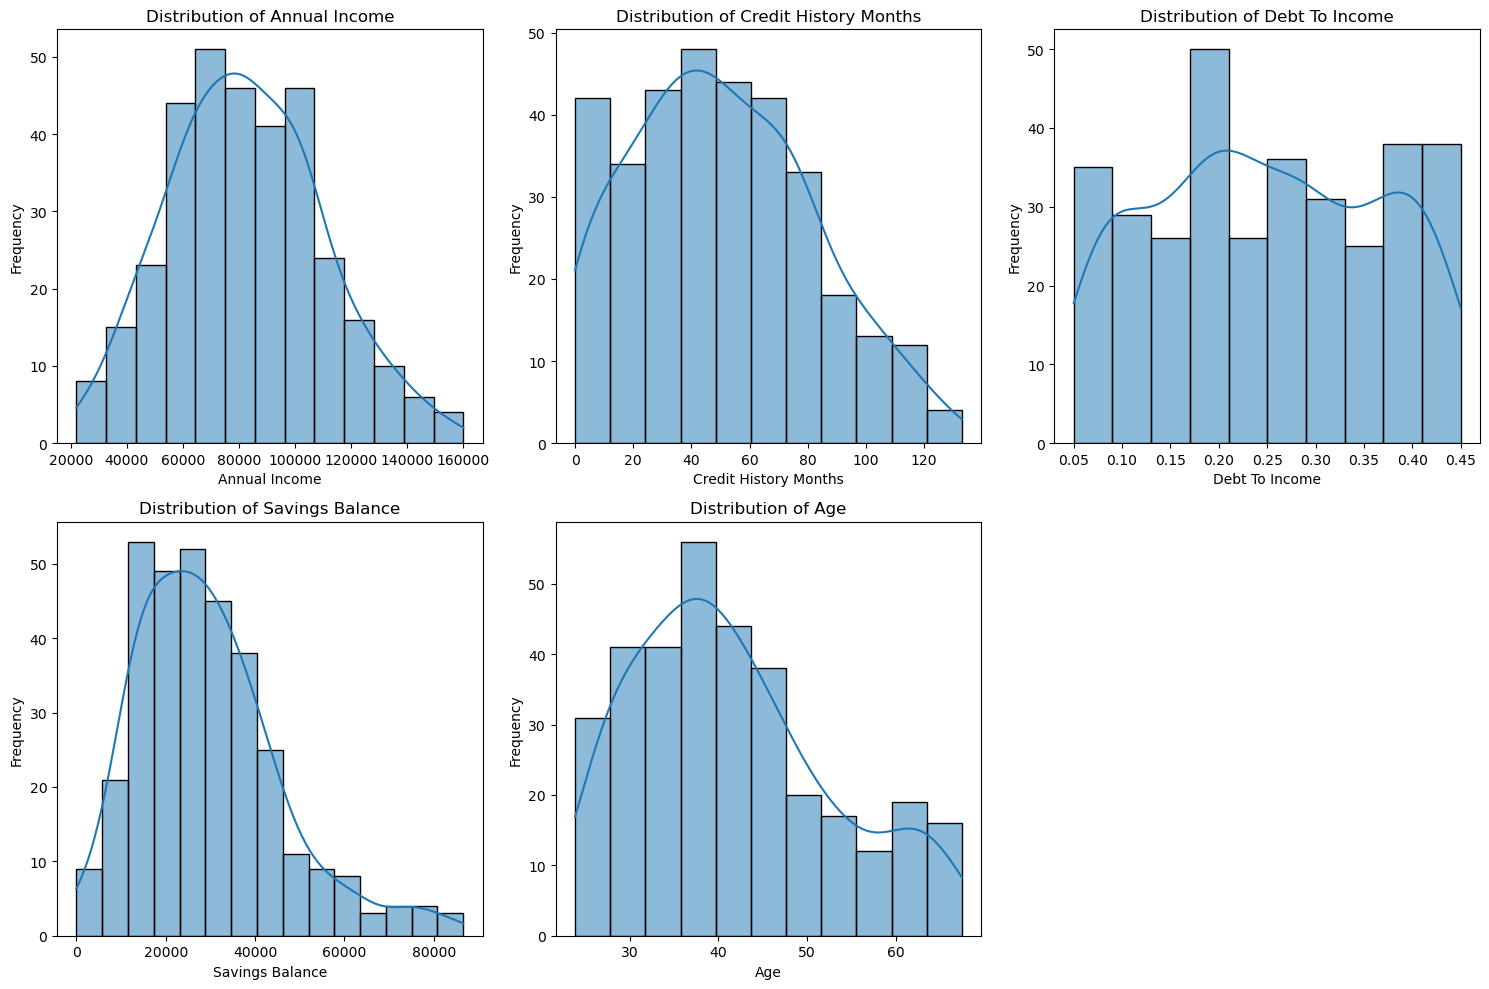

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_to_plot = ['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()